# HomeWork12

### Импорт библиотек и настройка окружения

In [21]:
# Импорт библиотек
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Фиксируем seed для воспроизводимости
SEED = 47

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Определяем устройство для вычислений
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cpu


### Загрузка и первичный анализ данных

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


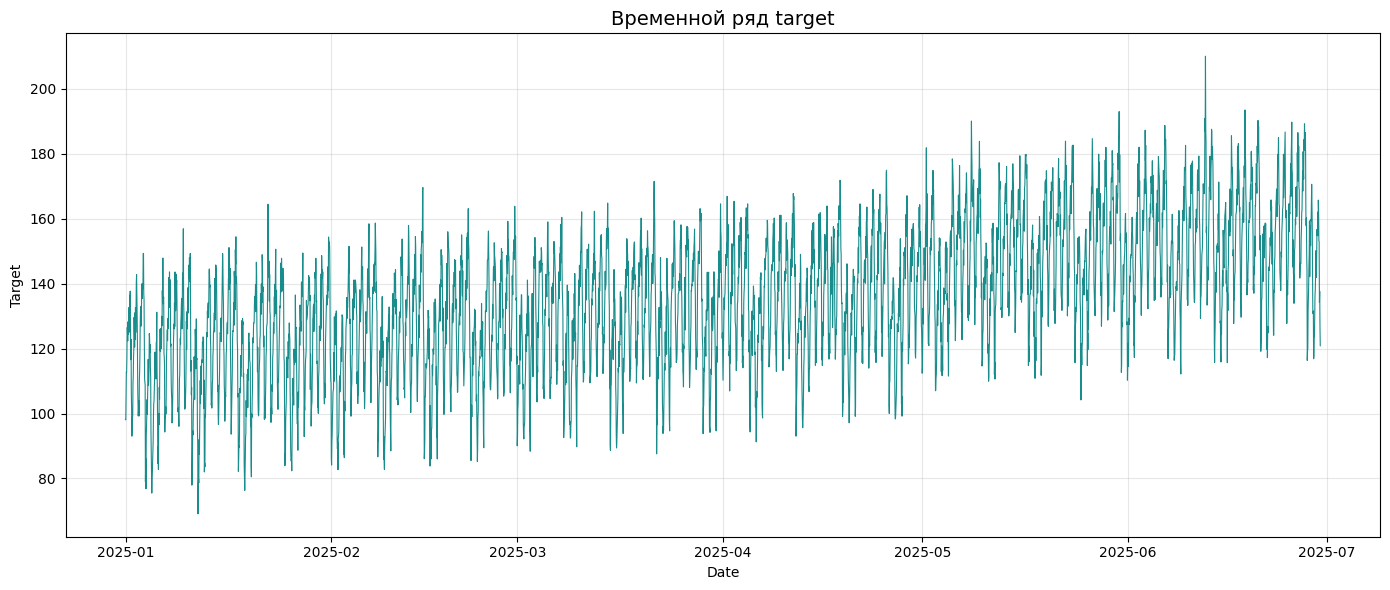

In [22]:
# Загрузка данных из CSV
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "—", df["date"].max())

print("\nПропуски по колонкам:")
print(df.isna().sum())

# Визуализация исходного временного ряда
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["target"], linewidth=0.8, color='teal', alpha=0.9)
plt.title("Временной ряд target", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Анализ ряда:**
- Наблюдается явный восходящий тренд. Средний уровень последовательно растёт.
- Присутствуют регулярные суточные колебания (сезонность).
- Отдельные выбросы не выглядят экстремальными.
- Ряд нестационарен (тренд + сезонность).

### Корректный temporal split

Train:
2025-01-01 00:00:00 — 2025-04-27 23:00:00 | size: 2808

Validation:
2025-04-28 00:00:00 — 2025-05-29 11:00:00 | size: 756

Test:
2025-05-29 12:00:00 — 2025-06-29 23:00:00 | size: 756


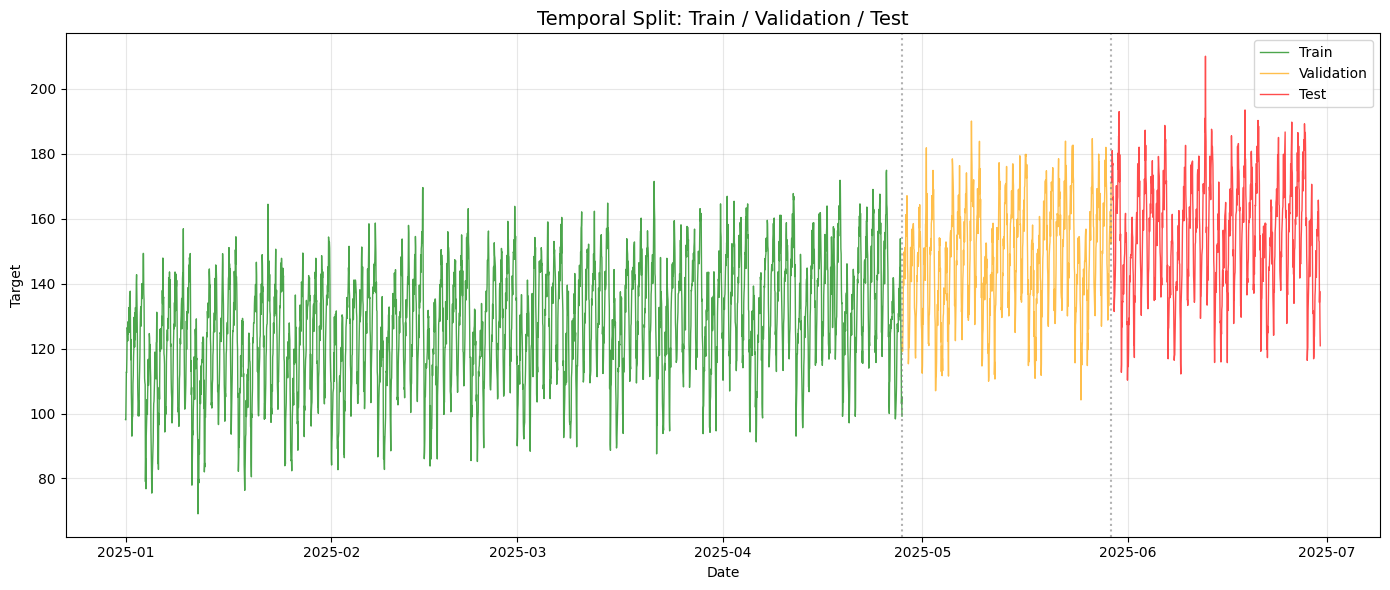

In [23]:
# Доли: 65% train, 17.5% validation, 17.5% test
n = len(df)
train_end = int(n * 0.65)
val_end = int(n * 0.825)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:")
print(train_df["date"].min(), "—", train_df["date"].max(), "| size:", len(train_df))
print("\nValidation:")
print(val_df["date"].min(), "—", val_df["date"].max(), "| size:", len(val_df))
print("\nTest:")
print(test_df["date"].min(), "—", test_df["date"].max(), "| size:", len(test_df))

# Визуализация разбиения с разными цветами
plt.figure(figsize=(14, 6))
plt.plot(train_df["date"], train_df["target"], label="Train", linewidth=1, color='green', alpha=0.7)
plt.plot(val_df["date"], val_df["target"], label="Validation", linewidth=1, color='orange', alpha=0.7)
plt.plot(test_df["date"], test_df["target"], label="Test", linewidth=1, color='red', alpha=0.7)
plt.axvline(x=train_df["date"].max(), color='gray', linestyle=':', alpha=0.6)
plt.axvline(x=val_df["date"].max(), color='gray', linestyle=':', alpha=0.6)
plt.title("Temporal Split: Train / Validation / Test", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()

Случайное разделение (random split) перемешивает данные из разных временных периодов, что вызывает утечку информации из data leakage, который будет в будущем. Это приводит к завышенной оценке качества модели и искажает причинную структуру временных рядов. Поэтому для анализа используется только temporal split и не подходит random split.

### Построение признаков для baseline-моделей

In [24]:
# Создание признаков на основе исходного датафрейма
df_features = df.copy()

# Лаговые признаки
df_features["lag_1"] = df_features["target"].shift(1)
df_features["lag_7"] = df_features["target"].shift(7)
df_features["lag_14"] = df_features["target"].shift(14)

# Скользящие статистики (окно 7) — shift(1) исключает утечку из будущего
df_features["rolling_mean_7"] = df_features["target"].shift(1).rolling(window=7).mean()
df_features["rolling_std_7"] = df_features["target"].shift(1).rolling(window=7).std()

# Календарные признаки
df_features["day_of_week"] = df_features["date"].dt.dayofweek
df_features["month"] = df_features["date"].dt.month
df_features["hour"] = df_features["date"].dt.hour

# Удаление строк с NaN, появившихся из-за сдвигов
df_features = df_features.dropna().reset_index(drop=True)

print("Признаки:")
print(df_features.columns.tolist())
print("\nРазмер после удаления NaN ->", len(df_features))

# Temporal split по тем же датам, что и основной split (train_df / val_df / test_df)
# Это гарантирует, что все модели оцениваются на одинаковых временных периодах
train_features = df_features[df_features["date"] <= train_df["date"].max()].copy()
val_features = df_features[
    (df_features["date"] > train_df["date"].max()) &
    (df_features["date"] <= val_df["date"].max())
].copy()
test_features = df_features[df_features["date"] > val_df["date"].max()].copy()

print("\nРазмеры после split (по датам основного split):")
print("Train ->", len(train_features))
print("Validation ->", len(val_features))
print("Test ->", len(test_features))

Признаки:
['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'hour']

Размер после удаления NaN -> 4306

Размеры после split (по датам основного split):
Train -> 2794
Validation -> 756
Test -> 756


### Подготовка оконного представления для GRU

In [25]:
# Параметры окна
window_size = 36  # 36 часов
series = df["target"].values.astype("float32")

n = len(series)
train_end = int(n * 0.65)
val_end = int(n * 0.825)

train_series = series[:train_end]
val_series = series[train_end:val_end]
test_series = series[val_end:]

# Масштабирование (fit только на train)
scaler = StandardScaler()
train_series_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
val_series_scaled = scaler.transform(val_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

print("Масштабирование выполнено (fit только на train)")
print("Train mean после scaling ->", train_series_scaled.mean())
print("Train std после scaling ->", train_series_scaled.std())

def create_windows(series, window):
    X = []
    y = []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

X_train_gru, y_train_gru = create_windows(train_series_scaled, window_size)
X_val_gru, y_val_gru = create_windows(val_series_scaled, window_size)
X_test_gru, y_test_gru = create_windows(test_series_scaled, window_size)

print("\nФормы данных для GRU:")
print("X_train ->", X_train_gru.shape, "| y_train ->", y_train_gru.shape)
print("X_val ->", X_val_gru.shape, "| y_val ->", y_val_gru.shape)
print("X_test ->", X_test_gru.shape, "| y_test ->", y_test_gru.shape)

# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 96
train_dataset = TimeSeriesDataset(X_train_gru, y_train_gru)
val_dataset = TimeSeriesDataset(X_val_gru, y_val_gru)
test_dataset = TimeSeriesDataset(X_test_gru, y_test_gru)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("\nDataLoader создан:")
print("Train batches ->", len(train_loader))
print("Val batches ->", len(val_loader))
print("Test batches ->", len(test_loader))

Масштабирование выполнено (fit только на train)
Train mean после scaling -> -9.781275e-08
Train std после scaling -> 1.0

Формы данных для GRU:
X_train -> (2772, 36) | y_train -> (2772,)
X_val -> (720, 36) | y_val -> (720,)
X_test -> (720, 36) | y_test -> (720,)

DataLoader создан:
Train batches -> 29
Val batches -> 8
Test batches -> 8


### Определение модели GRU и вспомогательных функций

In [26]:
# Модель GRU с одним слоем
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()

# Функция обучения одной эпохи
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

# Функция оценки на валидации/тесте
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            loss = criterion(pred, y)
            total_loss += loss.item() * X.size(0)
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    mse = ((preds - targets) ** 2).mean()
    mae = np.abs(preds - targets).mean()
    return total_loss / len(loader.dataset), mse, mae

# Расчёт метрик MAE, RMSE, MAPE
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    return mae, rmse, mape

### Логирование результатов экспериментов

In [27]:
# Создаём папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

In [28]:
experiment_results = []

def log_experiment(exp_id, model_name, val_true, val_pred,
                test_true, test_pred, window_size=None,
                features="", optimizer="", lr=0, epochs=0,
                scaler_name="None", notes=""):
    val_mae, val_rmse, val_mape = calculate_metrics(val_true, val_pred)
    test_mae, test_rmse, test_mape = calculate_metrics(test_true, test_pred)

    run = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": SEED,
        "split_summary": "65/17.5/17.5 (Temporal)",
        "window_size": window_size if window_size else "N/A",
        "horizon": 1,
        "model_summary": model_name,
        "features_summary": features,
        "scaler": scaler_name,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_mae": val_mae,
        "best_val_rmse": val_rmse,
        "best_val_mape": val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes
    }
    experiment_results.append(run)
    print(f"[{exp_id}] Val MAE -> {val_mae:.4f}, Test MAE -> {test_mae:.4f}")
    return val_mae

### Эксперименты

#### B1: Naive‑last (прогноз = последнее значение)

In [29]:
def naive_last_forecast(train, val, test):
    val_pred = np.roll(val, 1)
    val_pred[0] = train[-1]
    test_pred = np.roll(test, 1)
    test_pred[0] = val[-1]
    return val_pred, test_pred

val_pred_b1, test_pred_b1 = naive_last_forecast(train_series, val_series, test_series)
log_experiment("B1", "naive-last",
            val_true=val_series, val_pred=val_pred_b1,
            test_true=test_series, test_pred=test_pred_b1,
            features="y_{t-1}",
            scaler_name="None",
            notes="Baseline -> y_t = y_{t-1}")

[B1] Val MAE -> 6.5203, Test MAE -> 6.3304


6.520330429077148

#### B2: Moving Average (окно 7)

In [30]:
def moving_average_forecast(train, val, test, window=7):
    val_pred = np.zeros_like(val)
    for i in range(len(val)):
        if i == 0:
            history = train[-window:]
        else:
            context = list(train[-window:]) + list(val[:i])
            history = context[-window:]
        val_pred[i] = np.mean(history)

    test_pred = np.zeros_like(test)
    for i in range(len(test)):
        if i == 0:
            history = val[-window:]
        else:
            context = list(val[-window:]) + list(test[:i])
            history = context[-window:]
        test_pred[i] = np.mean(history)
    return val_pred, test_pred

ma_window = 7
val_pred_b2, test_pred_b2 = moving_average_forecast(train_series, val_series, test_series, ma_window)

log_experiment("B2", f"Moving Average (w={ma_window})",
            val_true=val_series, val_pred=val_pred_b2,
            test_true=test_series, test_pred=test_pred_b2,
            window_size=ma_window,
            features=f"SlidingMean({ma_window})",
            scaler_name="None",
            notes=f"Sliding window mean size {ma_window}")

[B2] Val MAE -> 12.6111, Test MAE -> 12.8385


12.611083030700684

#### B3: Ridge regression с лаговыми и календарными признаками

In [31]:
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "month", "hour"
]

# Используем train_features / val_features / test_features из предыдущей ячейки —
# они уже разбиты по тем же датовым границам, что и основной temporal split
X_train_ridge = train_features[feature_cols].values
X_val_ridge   = val_features[feature_cols].values
X_test_ridge  = test_features[feature_cols].values

y_train_ridge = train_features["target"].values
y_val_ridge   = val_features["target"].values
y_test_ridge  = test_features["target"].values

# Масштабирование: fit только на train
ridge_scaler = StandardScaler()
X_train_ridge_sc = ridge_scaler.fit_transform(X_train_ridge)
X_val_ridge_sc   = ridge_scaler.transform(X_val_ridge)
X_test_ridge_sc  = ridge_scaler.transform(X_test_ridge)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_ridge_sc, y_train_ridge)

val_pred_b3  = ridge_model.predict(X_val_ridge_sc)
test_pred_b3 = ridge_model.predict(X_test_ridge_sc)

log_experiment("B3", "Ridge Regression",
            val_true=y_val_ridge, val_pred=val_pred_b3,
            test_true=y_test_ridge, test_pred=test_pred_b3,
            features="Lags(1,7,14), RollMean(7), RollStd(7), Time features",
            optimizer="Closed-form",
            scaler_name="StandardScaler",
            notes="Linear model with engineered features")

[B3] Val MAE -> 5.8323, Test MAE -> 5.7591


5.832266514349317

#### R1: GRU (рекуррентная нейронная сеть)

In [32]:
hidden_size = 64
lr_gru = 2e-3   # скорость обучения
epochs_gru = 20

gru_model = GRUModel(input_size=1, hidden_size=hidden_size, num_layers=1).to(device)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=lr_gru)
criterion = nn.MSELoss()

loss_history = []
mae_history = []

best_val_loss = float('inf')

for epoch in range(epochs_gru):
    train_loss = train_epoch(gru_model, train_loader, optimizer_gru, criterion, device)
    val_loss, _, val_mae = evaluate(gru_model, val_loader, criterion, device)

    loss_history.append(train_loss)
    mae_history.append(val_mae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")
        config = {
            "window_size": window_size,
            "hidden_size": hidden_size,
            "num_layers": 1,
            "batch_size": batch_size,
            "learning_rate": lr_gru,
            "epochs": epochs_gru,
            "seed": SEED,
            "architecture": "GRU(1->64->1)",
            "scaler": "StandardScaler"
        }
        with open("artifacts/best_gru_config.json", "w") as f:
            json.dump(config, f, indent=4)

    print(f"Epoch {epoch+1}/{epochs_gru} | train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | val_mae={val_mae:.4f}")

# Загрузка лучшей модели
gru_model.load_state_dict(torch.load("artifacts/best_gru.pt"))
gru_model.eval()

# Сбор предсказаний в масштабированном виде
val_preds_scaled = []
val_targets_scaled = []
test_preds_scaled = []
test_targets_scaled = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        pred = gru_model(X)
        val_preds_scaled.append(pred.cpu().numpy())
        val_targets_scaled.append(y.numpy())
    for X, y in test_loader:
        X = X.to(device)
        pred = gru_model(X)
        test_preds_scaled.append(pred.cpu().numpy())
        test_targets_scaled.append(y.numpy())

val_preds_scaled = np.concatenate(val_preds_scaled)
val_targets_scaled = np.concatenate(val_targets_scaled)
test_preds_scaled = np.concatenate(test_preds_scaled)
test_targets_scaled = np.concatenate(test_targets_scaled)

# Обратное масштабирование
val_pred_r1  = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
val_true_r1  = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).flatten()
test_pred_r1 = scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()
test_true_r1 = scaler.inverse_transform(test_targets_scaled.reshape(-1, 1)).flatten()

log_experiment("R1", "GRU Neural Network",
            val_true=val_true_r1, val_pred=val_pred_r1,
            test_true=test_true_r1, test_pred=test_pred_r1,
            window_size=window_size,
            features="Raw scaled sequence",
            optimizer="Adam",
            lr=lr_gru,
            epochs=epochs_gru,
            scaler_name="StandardScaler",
            notes=f"Hidden size {hidden_size}, Best Val Loss {best_val_loss:.4f}")

Epoch 1/20 | train_loss=0.6026 | val_loss=0.4391 | val_mae=0.5503
Epoch 2/20 | train_loss=0.1971 | val_loss=0.1913 | val_mae=0.3525
Epoch 3/20 | train_loss=0.1683 | val_loss=0.2463 | val_mae=0.4018
Epoch 4/20 | train_loss=0.1593 | val_loss=0.2048 | val_mae=0.3658
Epoch 5/20 | train_loss=0.1543 | val_loss=0.2078 | val_mae=0.3682
Epoch 6/20 | train_loss=0.1502 | val_loss=0.2504 | val_mae=0.4055
Epoch 7/20 | train_loss=0.1493 | val_loss=0.2161 | val_mae=0.3752
Epoch 8/20 | train_loss=0.1452 | val_loss=0.2128 | val_mae=0.3706
Epoch 9/20 | train_loss=0.1416 | val_loss=0.2057 | val_mae=0.3619
Epoch 10/20 | train_loss=0.1210 | val_loss=0.1563 | val_mae=0.3099
Epoch 11/20 | train_loss=0.1107 | val_loss=0.1488 | val_mae=0.3026
Epoch 12/20 | train_loss=0.1081 | val_loss=0.1442 | val_mae=0.2960
Epoch 13/20 | train_loss=0.1082 | val_loss=0.1354 | val_mae=0.2813
Epoch 14/20 | train_loss=0.1063 | val_loss=0.1697 | val_mae=0.3231
Epoch 15/20 | train_loss=0.1037 | val_loss=0.1584 | val_mae=0.3117
Epoc

5.108063220977783

### Сравнение моделей и выбор лучшей

In [33]:
# Сохранение таблицы результатов
df_results = pd.DataFrame(experiment_results)
df_results.to_csv("artifacts/runs.csv", index=False)
print(df_results[['experiment_id', 'best_val_mae', 'test_mae']].sort_values('best_val_mae'))

best_row = df_results.loc[df_results['best_val_mae'].idxmin()]
best_exp_id = best_row['experiment_id']
print(f"\nЛучшая модель по Validation MAE -> {best_exp_id}")

  experiment_id  best_val_mae   test_mae
3            R1      5.108063   5.489541
2            B3      5.832267   5.759062
0            B1      6.520330   6.330397
1            B2     12.611083  12.838513

Лучшая модель по Validation MAE -> R1


### Визуализация результатов

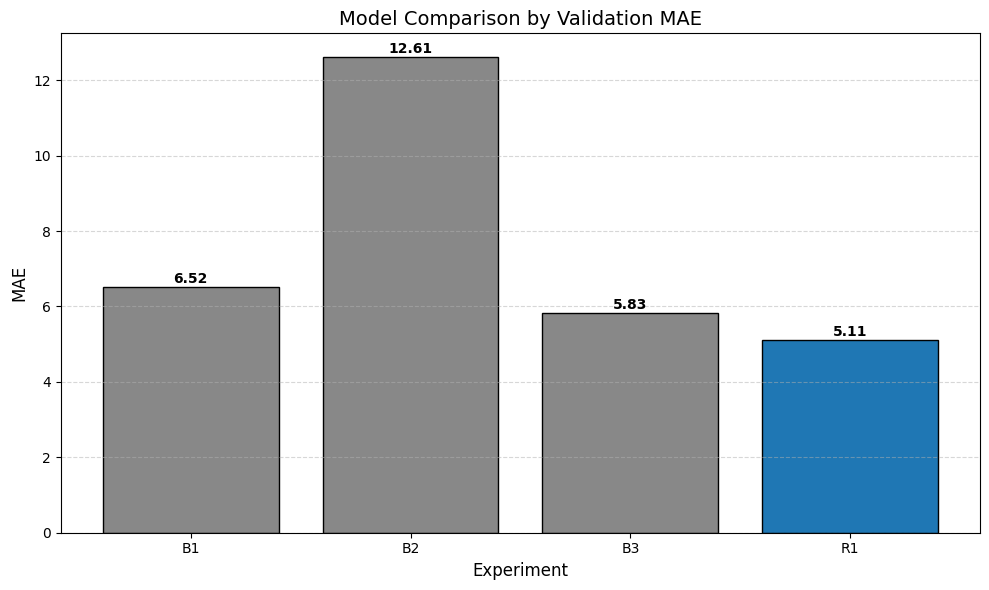

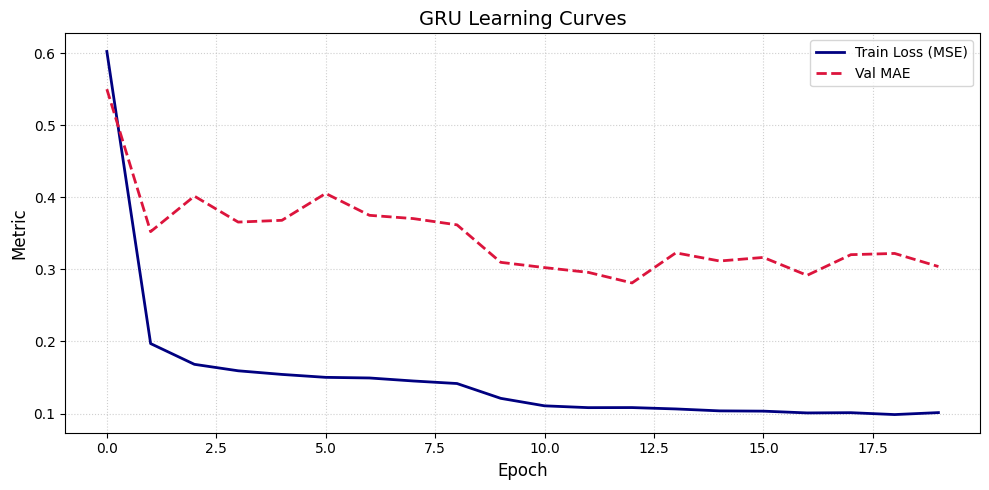

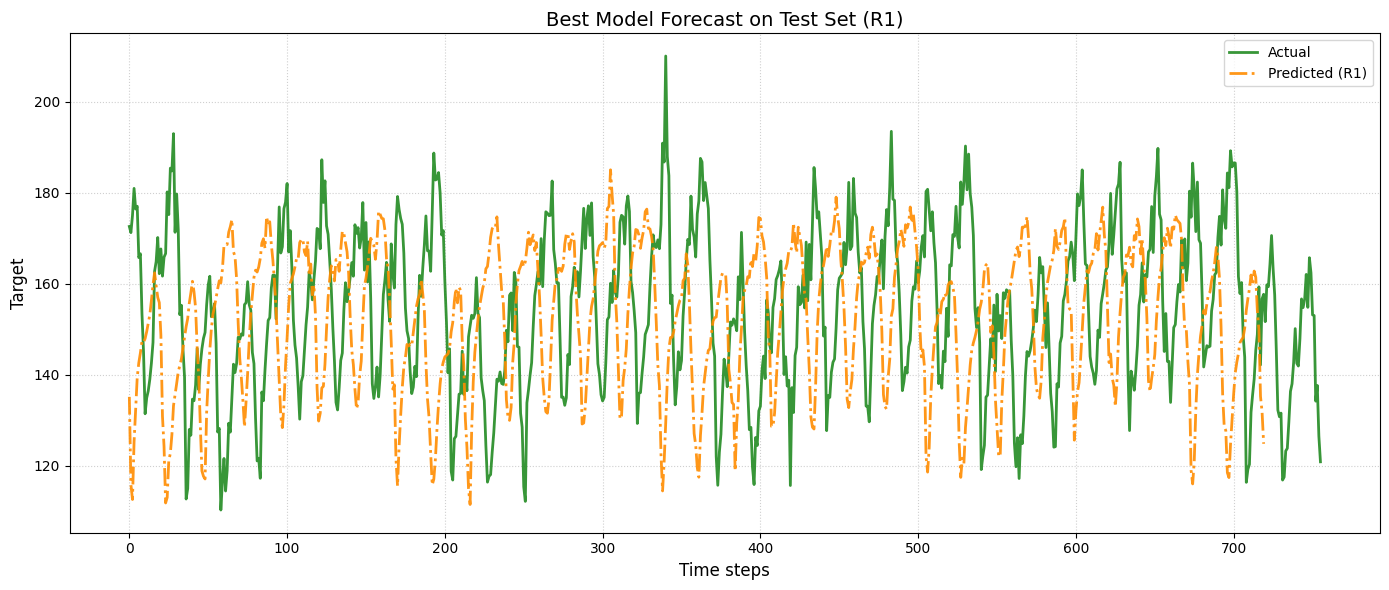

Графики сохранены


In [34]:
# График сравнения baseline моделей
plt.figure(figsize=(10, 6))
colors = ['#888888', '#888888', '#888888', '#1f77b4']
plt.bar(df_results['experiment_id'], df_results['best_val_mae'], color=colors, edgecolor='black', linewidth=1)
plt.title('Model Comparison by Validation MAE', fontsize=14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Experiment', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(df_results['best_val_mae']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# Кривые обучения GRU
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Train Loss (MSE)', linewidth=2, color='navy', linestyle='-')
plt.plot(mae_history, label='Val MAE', linewidth=2, color='crimson', linestyle='--')
plt.title('GRU Learning Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Прогноз лучшей модели на тестовой выборке
if best_exp_id == 'B1':
    y_pred_best = test_pred_b1
elif best_exp_id == 'B2':
    y_pred_best = test_pred_b2
elif best_exp_id == 'B3':
    y_pred_best = test_pred_b3
else:  # R1
    y_pred_best = test_pred_r1

y_true_best = test_series

plt.figure(figsize=(14, 6))
plt.plot(y_true_best, label='Actual', linewidth=2, color='forestgreen', alpha=0.9)
plt.plot(y_pred_best, label=f'Predicted ({best_exp_id})', linestyle='-.', linewidth=2, color='darkorange', alpha=0.9)
plt.title(f'Best Model Forecast on Test Set ({best_exp_id})', fontsize=14)
plt.xlabel('Time steps', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

print("Графики сохранены")

---

## Опциональная часть

### О1: Сравнение GRU и LSTM

Используется та же постановка: `window_size=36`, `hidden_size=64`, Adam `lr=2e-3`, 20 эпох, `seed=47`.
Оба варианта применяются к одинаковым DataLoader-ам, что обеспечивает корректное сравнение без влияния данных.

In [ ]:
# LSTM — та же архитектура, слой GRU заменён на LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

torch.manual_seed(SEED)
np.random.seed(SEED)

lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=1).to(device)
opt_lstm   = optim.Adam(lstm_model.parameters(), lr=lr_gru)
crit_lstm  = nn.MSELoss()

loss_hist_lstm = []
mae_hist_lstm  = []
best_val_loss_lstm = float('inf')

for epoch in range(epochs_gru):
    tr_loss = train_epoch(lstm_model, train_loader, opt_lstm, crit_lstm, device)
    vl_loss, _, vl_mae = evaluate(lstm_model, val_loader, crit_lstm, device)
    loss_hist_lstm.append(tr_loss)
    mae_hist_lstm.append(vl_mae)
    if vl_loss < best_val_loss_lstm:
        best_val_loss_lstm = vl_loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs_gru} | train={tr_loss:.4f} | val_loss={vl_loss:.4f} | val_mae={vl_mae:.4f}")

lstm_model.eval()
vp_s, vt_s, tp_s, tt_s = [], [], [], []
with torch.no_grad():
    for X, y in val_loader:
        vp_s.append(lstm_model(X.to(device)).cpu().numpy())
        vt_s.append(y.numpy())
    for X, y in test_loader:
        tp_s.append(lstm_model(X.to(device)).cpu().numpy())
        tt_s.append(y.numpy())

val_pred_lstm  = scaler.inverse_transform(np.concatenate(vp_s).reshape(-1, 1)).flatten()
val_true_lstm  = scaler.inverse_transform(np.concatenate(vt_s).reshape(-1, 1)).flatten()
test_pred_lstm = scaler.inverse_transform(np.concatenate(tp_s).reshape(-1, 1)).flatten()
test_true_lstm = scaler.inverse_transform(np.concatenate(tt_s).reshape(-1, 1)).flatten()

log_experiment("O1_LSTM", "LSTM Neural Network",
               val_true=val_true_lstm, val_pred=val_pred_lstm,
               test_true=test_true_lstm, test_pred=test_pred_lstm,
               window_size=window_size,
               features="Raw scaled sequence",
               optimizer="Adam", lr=lr_gru, epochs=epochs_gru,
               scaler_name="StandardScaler",
               notes=f"LSTM hidden=64, Best Val Loss {best_val_loss_lstm:.4f}")

# Сравнительный график кривых обучения GRU vs LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(loss_history,   label="GRU train loss",  linewidth=2, color="navy")
axes[0].plot(loss_hist_lstm, label="LSTM train loss", linewidth=2, color="crimson", linestyle="--")
axes[0].set_title("Train Loss: GRU vs LSTM")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(mae_history,   label="GRU val MAE",  linewidth=2, color="navy")
axes[1].plot(mae_hist_lstm, label="LSTM val MAE", linewidth=2, color="crimson", linestyle="--")
axes[1].set_title("Val MAE: GRU vs LSTM")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (scaled)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/gru_vs_lstm.png", dpi=150)
plt.show()

gru_vm, gru_rmse, gru_mape   = calculate_metrics(val_true_r1, val_pred_r1)
lstm_vm, lstm_rmse, lstm_mape = calculate_metrics(val_true_lstm, val_pred_lstm)
print(f"{'Model':<10} | {'val_MAE':>8} | {'val_RMSE':>9} | {'val_MAPE':>9}")
print("-" * 45)
print(f"{'GRU':<10} | {gru_vm:>8.4f} | {gru_rmse:>9.4f} | {gru_mape:>8.2f}%")
print(f"{'LSTM':<10} | {lstm_vm:>8.4f} | {lstm_rmse:>9.4f} | {lstm_mape:>8.2f}%")

### О2: Подбор window_size для GRU

Сравниваем три варианта длины входного окна: **12, 24, 36 шагов** (часов).
Для каждого варианта обучается отдельная GRU с одинаковыми гиперпараметрами (`hidden_size=64`, Adam `lr=2e-3`, 20 эпох).
Лучший `window_size` выбирается по минимальному Val MAE.

In [ ]:
window_sizes_to_try = [12, 24, 36]
ws_results = {}

for ws in window_sizes_to_try:
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    X_tr, y_tr = create_windows(train_series_scaled, ws)
    X_vl, y_vl = create_windows(val_series_scaled, ws)
    X_te, y_te = create_windows(test_series_scaled, ws)

    tr_loader_ws = DataLoader(TimeSeriesDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    vl_loader_ws = DataLoader(TimeSeriesDataset(X_vl, y_vl), batch_size=batch_size)
    te_loader_ws = DataLoader(TimeSeriesDataset(X_te, y_te), batch_size=batch_size)

    model_ws = GRUModel(input_size=1, hidden_size=64, num_layers=1).to(device)
    opt_ws   = optim.Adam(model_ws.parameters(), lr=2e-3)
    crit_ws  = nn.MSELoss()

    best_val_loss_ws = float('inf')
    best_state = None

    for epoch in range(20):
        train_epoch(model_ws, tr_loader_ws, opt_ws, crit_ws, device)
        vl_loss, _, _ = evaluate(model_ws, vl_loader_ws, crit_ws, device)
        if vl_loss < best_val_loss_ws:
            best_val_loss_ws = vl_loss
            best_state = {k: v.clone() for k, v in model_ws.state_dict().items()}

    model_ws.load_state_dict(best_state)
    model_ws.eval()

    vp, vt, tp, tt = [], [], [], []
    with torch.no_grad():
        for X, y in vl_loader_ws:
            vp.append(model_ws(X.to(device)).cpu().numpy())
            vt.append(y.numpy())
        for X, y in te_loader_ws:
            tp.append(model_ws(X.to(device)).cpu().numpy())
            tt.append(y.numpy())

    val_pred_ws  = scaler.inverse_transform(np.concatenate(vp).reshape(-1, 1)).flatten()
    val_true_ws  = scaler.inverse_transform(np.concatenate(vt).reshape(-1, 1)).flatten()
    test_pred_ws = scaler.inverse_transform(np.concatenate(tp).reshape(-1, 1)).flatten()
    test_true_ws = scaler.inverse_transform(np.concatenate(tt).reshape(-1, 1)).flatten()

    val_mae_ws, _, _ = calculate_metrics(val_true_ws, val_pred_ws)
    test_mae_ws, _, _ = calculate_metrics(test_true_ws, test_pred_ws)
    ws_results[ws] = {"val_mae": val_mae_ws, "test_mae": test_mae_ws}

    log_experiment(f"O2_ws{ws}", f"GRU (window_size={ws})",
                   val_true=val_true_ws, val_pred=val_pred_ws,
                   test_true=test_true_ws, test_pred=test_pred_ws,
                   window_size=ws, features="Raw scaled sequence",
                   optimizer="Adam", lr=2e-3, epochs=20,
                   scaler_name="StandardScaler",
                   notes=f"Window size search, ws={ws}")
    print(f"window_size={ws:>3} | val_MAE={val_mae_ws:.4f} | test_MAE={test_mae_ws:.4f}")

best_ws = min(ws_results, key=lambda w: ws_results[w]["val_mae"])
print(f"\nЛучший window_size = {best_ws} (val_MAE={ws_results[best_ws]['val_mae']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_colors = ["#1f77b4" if ws == best_ws else "#aec7e8" for ws in window_sizes_to_try]

axes[0].bar([str(w) for w in window_sizes_to_try],
            [ws_results[w]["val_mae"] for w in window_sizes_to_try],
            color=bar_colors, edgecolor="black")
axes[0].set_title("Val MAE by window_size"); axes[0].set_xlabel("window_size"); axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for i, w in enumerate(window_sizes_to_try):
    axes[0].text(i, ws_results[w]["val_mae"] + 0.05, f"{ws_results[w]['val_mae']:.2f}", ha="center", fontsize=10, fontweight="bold")

axes[1].bar([str(w) for w in window_sizes_to_try],
            [ws_results[w]["test_mae"] for w in window_sizes_to_try],
            color=bar_colors, edgecolor="black")
axes[1].set_title("Test MAE by window_size"); axes[1].set_xlabel("window_size"); axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for i, w in enumerate(window_sizes_to_try):
    axes[1].text(i, ws_results[w]["test_mae"] + 0.05, f"{ws_results[w]['test_mae']:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("GRU Window Size Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/figures/window_size_compare.png", dpi=150)
plt.show()

### О3: Gradient Boosting как альтернатива Ridge (B3)

Те же признаки и масштабирование, что у Ridge — корректное сравнение «один к одному».

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb_model.fit(X_train_ridge_sc, y_train_ridge)

val_pred_o3  = gb_model.predict(X_val_ridge_sc)
test_pred_o3 = gb_model.predict(X_test_ridge_sc)

log_experiment("O3_GBR", "Gradient Boosting Regression",
               val_true=y_val_ridge, val_pred=val_pred_o3,
               test_true=y_test_ridge, test_pred=test_pred_o3,
               features="Lags(1,7,14), RollMean(7), RollStd(7), Time features",
               optimizer="GradientBoosting", scaler_name="StandardScaler",
               notes="n_estimators=300, max_depth=4, lr=0.05, subsample=0.8")

b3_vm, b3_vr, b3_vp = calculate_metrics(y_val_ridge, val_pred_b3)
o3_vm, o3_vr, o3_vp = calculate_metrics(y_val_ridge, val_pred_o3)
b3_tm, b3_tr, b3_tp = calculate_metrics(y_test_ridge, test_pred_b3)
o3_tm, o3_tr, o3_tp = calculate_metrics(y_test_ridge, test_pred_o3)

print(f"{'Model':<28} | {'val_MAE':>7} | {'val_RMSE':>8} | {'val_MAPE':>8} | {'test_MAE':>8} | {'test_RMSE':>9}")
print("-" * 80)
print(f"{'B3: Ridge Regression':<28} | {b3_vm:>7.4f} | {b3_vr:>8.4f} | {b3_vp:>7.2f}% | {b3_tm:>8.4f} | {b3_tr:>9.4f}")
print(f"{'O3: Gradient Boosting':<28} | {o3_vm:>7.4f} | {o3_vr:>8.4f} | {o3_vp:>7.2f}% | {o3_tm:>8.4f} | {o3_tr:>9.4f}")

n_show = 200
plt.figure(figsize=(14, 5))
plt.plot(y_test_ridge[:n_show], label="Actual", linewidth=1.5, color="forestgreen")
plt.plot(test_pred_b3[:n_show], label="Ridge (B3)", linestyle="--", linewidth=1.5, color="steelblue", alpha=0.85)
plt.plot(test_pred_o3[:n_show], label="Gradient Boosting (O3)", linestyle="-.", linewidth=1.5, color="darkorange", alpha=0.85)
plt.title("Ridge vs Gradient Boosting — Test Set (first 200 steps)", fontsize=13)
plt.xlabel("Time steps"); plt.ylabel("Target")
plt.legend(); plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("artifacts/figures/ridge_vs_gbr.png", dpi=150)
plt.show()

### О4: Анализ ошибок на характерных участках

Для лучшей модели (R1 — GRU) находим 5 участков test-выборки с наибольшей абсолютной ошибкой и визуализируем каждый с контекстом ±12 шагов.

In [ ]:
abs_errors   = np.abs(test_true_r1 - test_pred_r1)
signed_errors = test_true_r1 - test_pred_r1

CONTEXT  = 12
MIN_DIST = CONTEXT

sorted_idx  = np.argsort(abs_errors)[::-1]
peak_indices = []
for idx in sorted_idx:
    if all(abs(idx - p) >= MIN_DIST for p in peak_indices):
        peak_indices.append(idx)
    if len(peak_indices) == 5:
        break
peak_indices = sorted(peak_indices)

fig, axes = plt.subplots(5, 1, figsize=(14, 20))
fig.suptitle("GRU (R1) — Анализ ошибок на характерных участках test",
             fontsize=14, fontweight="bold", y=1.01)

for ax, center in zip(axes, peak_indices):
    lo = max(0, center - CONTEXT)
    hi = min(len(test_true_r1) - 1, center + CONTEXT)
    x  = np.arange(lo, hi + 1)

    ax.plot(x, test_true_r1[lo:hi+1], label="Actual", color="forestgreen", linewidth=2)
    ax.plot(x, test_pred_r1[lo:hi+1], label="GRU pred", linestyle="--", color="darkorange", linewidth=2)
    ax.fill_between(x, test_true_r1[lo:hi+1], test_pred_r1[lo:hi+1],
                    alpha=0.15, color="red", label="Error")
    ax.axvline(center, color="red", linestyle=":", linewidth=1.5, alpha=0.8)
    err_val = signed_errors[center]
    ax.set_title(
        f"Пик ошибки @ step {center} | AE={abs_errors[center]:.2f} | "
        f"{'недооценка' if err_val > 0 else 'переоценка'} на {abs(err_val):.2f}",
        fontsize=10, pad=8)
    ax.set_xlabel("Time step (test index)"); ax.set_ylabel("Target")
    ax.legend(loc="upper right", fontsize=8); ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig("artifacts/figures/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Step':>6} | {'AE':>8} | {'Actual':>10} | {'Predicted':>10} | {'Direction'}")
print("-" * 55)
for idx in peak_indices:
    direction = "недооценка" if signed_errors[idx] > 0 else "переоценка"
    print(f"{idx:>6} | {abs_errors[idx]:>8.2f} | {test_true_r1[idx]:>10.2f} | {test_pred_r1[idx]:>10.2f} | {direction}")

# Финальное обновление runs.csv со всеми экспериментами
df_results_full = pd.DataFrame(experiment_results)
df_results_full.to_csv("artifacts/runs.csv", index=False)
print(f"\nruns.csv обновлён. Всего экспериментов: {len(df_results_full)}")

### О5: Дополнительные графики

Три визуализации, рекомендованные заданием:
- **residuals_best.png** — распределение остатков лучшей модели (GRU R1)
- **error_by_time.png** — ошибка модели по времени (скользящее среднее AE)
- **feature_examples.png** — примеры лаговых и rolling-признаков на фрагменте ряда

In [ ]:
# --- 1. residuals_best.png ---
residuals = test_true_r1 - test_pred_r1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].axvline(residuals.mean(), color="orange", linestyle="--", linewidth=1.5,
                label=f"mean={residuals.mean():.2f}")
axes[0].set_title("Распределение остатков GRU (R1) на test", fontsize=12)
axes[0].set_xlabel("Residual (Actual − Predicted)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.4)

axes[1].scatter(test_pred_r1, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Остатки vs Предсказанные значения", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("artifacts/figures/residuals_best.png", dpi=150)
plt.show()

# --- 2. error_by_time.png ---
rolling_ae = pd.Series(np.abs(residuals)).rolling(window=24, min_periods=1).mean().values

plt.figure(figsize=(14, 4))
plt.plot(np.abs(residuals), color="lightcoral", linewidth=0.8, alpha=0.6, label="AE (per step)")
plt.plot(rolling_ae, color="crimson", linewidth=2, label="Rolling mean AE (w=24)")
plt.axhline(np.abs(residuals).mean(), color="navy", linestyle="--", linewidth=1.5,
            label=f"Mean AE = {np.abs(residuals).mean():.2f}")
plt.title("Ошибка GRU (R1) по времени на test-выборке", fontsize=13)
plt.xlabel("Time step (test index)")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("artifacts/figures/error_by_time.png", dpi=150)
plt.show()

# --- 3. feature_examples.png ---
# Показываем фрагмент train (первые 120 точек) с лагами и rolling
frag = train_features.iloc[:120].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(frag.index, frag["target"], label="target", color="teal", linewidth=1.5)
axes[0].plot(frag.index, frag["lag_1"],  label="lag_1",  color="orange", linewidth=1, linestyle="--")
axes[0].plot(frag.index, frag["lag_7"],  label="lag_7",  color="purple", linewidth=1, linestyle=":")
axes[0].set_title("Лаговые признаки (первые 120 шагов train)", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=":", alpha=0.4)

axes[1].plot(frag.index, frag["target"],        label="target",         color="teal", linewidth=1.5)
axes[1].plot(frag.index, frag["rolling_mean_7"],label="rolling_mean_7", color="darkorange", linewidth=1.5)
axes[1].fill_between(frag.index,
                     frag["rolling_mean_7"] - frag["rolling_std_7"],
                     frag["rolling_mean_7"] + frag["rolling_std_7"],
                     alpha=0.15, color="darkorange", label="±rolling_std_7")
axes[1].set_title("Rolling mean ± std (окно 7)", fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=":", alpha=0.4)

axes[2].bar(frag.index, frag["hour"], color="steelblue", alpha=0.6, label="hour")
ax2 = axes[2].twinx()
ax2.plot(frag.index, frag["day_of_week"], color="crimson", linewidth=1.5, label="day_of_week")
axes[2].set_title("Календарные признаки: час и день недели", fontsize=11)
axes[2].set_ylabel("Hour"); ax2.set_ylabel("Day of week")
axes[2].legend(loc="upper left", fontsize=9); ax2.legend(loc="upper right", fontsize=9)
axes[2].grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("artifacts/figures/feature_examples.png", dpi=150)
plt.show()

print("Дополнительные графики сохранены:"
      "\n  artifacts/figures/residuals_best.png"
      "\n  artifacts/figures/error_by_time.png"
      "\n  artifacts/figures/feature_examples.png")